
实验名称 基于seq2seq模型的文字翻译\
实验数据：
eng-fra.txt 英语-法语对照数
实验要求：  
1、按照网址教程 ’https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html#sphx-glr-intermediate-seq2seq-translation-tutorial-py‘，复现使用RNN进行语言翻译的实验。  
2、删除教程中关于Attention的部分  
3、分析比较RNN和GRU结果的差异。  
4、更换数据eng-cmn.txt，进行上述实验，分析结果


## 加载eng-fra.txt数据集

In [1]:
from __future__ import unicode_literals, print_function, division  #用于让python2兼容python3的语法，常见于传统老旧的NLP项目中
                                                                   #其中unicode_literals用于解决多语言文本乱码及编码错误，print_function用于兼容python 3的print()语法，division用于兼容python 3的除法特性
from io import open
import unicodedata  #python内置库，专门处理 Unicode 字符标准化、字符属性查询，常用于NLP领域
import string
import re  #python内置库，re即Regular Expression（正则表达式）的首字母，正则表达式是用来匹配、查找、替换字符串的通用规则公式，市面上绝大多数编程语言和文本工具都支持正则表达式
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt


SOS_token = 0  #SOS和EOS是序列任务中的特殊标记符，用于界定序列的起始，其中SOS全称是Start of Sequence，EOS全称是End of Sequence
EOS_token = 1

"""
和之前实验报告中涉及的各种神经网络一样，我们总是习惯将一个具有若干抽象属性与抽象方法的事物高度封装成一个类，
之前都是class MyNeuralNetwork，但是在NLP领域我们还需要定义一个class Lang作为给单词分配数字编号的“词典工具”，或者说你可以认为它是一个集成了其他功能的哈希表
"""
class Lang:  #Lang就是Language，语言
    def __init__(self, name):
        self.name = name  #记录语言的名字，在本例中，eng->英语、fra->法语、cmn->中文
        self.word2index = {}  #从单词到数字下标的哈希表
        self.word2count = {}  #记录单词出现的数量
        self.index2word = {0: "SOS", 1: "EOS"}  #从数字下标到单词的哈希表，特别的，初始时就存在SOS（Start of Sequence）和EOS（End of Sequence）
        self.n_words = 2  #记录词汇量大小，特别的，由于我们已经有了SOS和EOS，因此self.n_words初始化值就是2

    def addSentence(self, sentence):
        if self.name == "cmn":  # 中文：按字拆分
            for char in sentence.strip():
                if char.strip():
                    self.addWord(char)
        else:  # 英文：按空格拆分
            for word in sentence.strip().split(' '):
                if word.strip():
                    self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:  #如果模型还没有见过这个单词的话
            self.word2index[word] = self.n_words  #给这个模型分配一个数字下标
            self.word2count[word] = 1  #由于之前没见过这个单词，现在才刚刚见到，所以该单词出现数量为1
            self.index2word[self.n_words] = word  #同理记录这个数字下标对应的单词
            self.n_words += 1  #词汇量大小+1
        else:  #如果模型已经见过了这个单词的话
            self.word2count[word] += 1  #只需要将该单词出现数量+1就行了

"""
法语、西班牙语、德语等语言中普遍存在重音符号、变音符号，若想要变成纯英文的ASCII字符就必须去掉它们
例如é → e、à → a、ç → c、ñ → n
"""
def unicodeToAscii(s):  #unicode转为Ascii
    return ''.join(  #最后拼起来
        c for c in unicodedata.normalize('NFD', s)  #NFD的全称是Normalization Form Decomposition，即“规范形式拆解”，此时会把特殊字符拆解为英文字母+特殊标记
        if unicodedata.category(c) != 'Mn'  #如果拆解出来的字符的类型不是特殊符号，则保留，反之则舍弃
    )

"""
特别的，在法语语法规范中，感叹号'!'和问号'?'前面需要要有一个空格，这和英语并不一样，但是句号'.'前面则不需要空格，这和英语是一样的
我们不妨将两种语言中的感叹号'!'、问号'?'以及句号'.'前面都加上一个空格以形成统一规范，这样能更好地提升模型的分词效果和翻译质量
"""

def normalizeString(s):
    s = s.lower().strip()
    # 1. 给所有标点前后加空格
    s = re.sub(r'([\?!.,，。？！])', r' \1 ', s)
    # 2. 保留：英文 + 中文 + 单引号' + 所有需要的标点 
    s = re.sub(r"[^a-zA-Z'\u4e00-\u9fff\?!.,，。？！]", ' ', s)
    # 3. 多余空格变一个
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

def readLangs(lang1, lang2, reverse=False):  #reverse用来翻转pair中的结果并输出，若reverse为Flase，则先打印lang1对应语言的句子后打印lang2对应语言的句子，反之易知
    print("正在记录数据集样本中......")
    
    file_name=str(lang1)+'-'+str(lang2)+'.txt'
    lines = open(file_name, encoding='utf-8').read().strip().split('\n')  #lines存储数据集中的每一行
    
    #为了加快训练，我们只取前500行
    lines = lines[:500]

    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    return input_lang, output_lang, pairs


MAX_LENGTH = 10  #为加快模型训练，我们直接筛除掉预处理后句子token数大于10的句子


def filterPair(p):  #仅考虑一个句子对中前一个句子和后一个句子的token数都小于10的情况
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH

def filterPairs(pairs):  #对每一个句子对都进行filterPair操作，得到最终的训练样本
    return [pair for pair in pairs if filterPair(pair)]

def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print(f'\n预处理前，有{len(pairs)}条有效句子对')
    pairs = filterPairs(pairs)
    print(f'预处理后，有{len(pairs)}条有效句子对\n')
    print("正在统计词汇量中......\n")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print(f'词汇量结果如下所示：')
    print(f'{input_lang.name}的词汇量大小为：{input_lang.n_words}')
    print(f'{output_lang.name}的词汇量大小为：{output_lang.n_words}')
    return input_lang, output_lang, pairs

input_lang1, output_lang1, pairs1 = prepareData('eng', 'fra', False) 

print("\n随机样本：", random.choice(pairs1))

正在记录数据集样本中......

预处理前，有500条有效句子对
预处理后，有500条有效句子对

正在统计词汇量中......

词汇量结果如下所示：
eng的词汇量大小为：220
fra的词汇量大小为：432

随机样本： ['wake up .', 'r veillez vous !']


## 加载eng-cmn.txt数据集

In [2]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F


SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2

    def addSentence(self, sentence):
        if self.name == 'cmn':  # 中文按字拆分
            for char in sentence:
                self.addWord(char)
        else:  # 英文按空格拆分
            for word in sentence.split(' '):
                self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1


def normalizeString(s):
    s = s.lower().strip()
    # 1. 给所有标点前后加空格
    s = re.sub(r'([\?!.,，。？！])', r' \1 ', s)
    # 2. 保留：英文 + 中文 + 单引号' + 所有需要的标点 
    s = re.sub(r"[^a-zA-Z'\u4e00-\u9fff\?!.,，。？！]", ' ', s)
    # 3. 多余空格变一个
    s = re.sub(r'\s+', ' ', s)
    return s.strip()
    

def readLangs(lang1, lang2, reverse=False):  #reverse用来翻转pair中的结果并输出，若reverse为Flase，则先打印lang1对应语言的句子后打印lang2对应语言的句子，反之易知
    print("正在记录数据集样本中......")
    
    file_name=str(lang1)+'-'+str(lang2)+'.txt'
    lines = open(file_name, encoding='utf-8').read().strip().split('\n')  #lines存储数据集中的每一行
    
    #为了加快训练，我们只取前500行
    lines = lines[:500]

    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    temp=[pair[:2] for pair in pairs]
    pairs=temp
    
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    return input_lang, output_lang, pairs
    

def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print(f'\n预处理前，有{len(pairs)}条有效句子对')
    pairs = filterPairs(pairs)
    print(f'预处理后，有{len(pairs)}条有效句子对\n')
    print("正在统计词汇量中......\n")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print(f'词汇量结果如下所示：')
    print(f'{input_lang.name}的词汇量大小为：{input_lang.n_words}')
    print(f'{output_lang.name}的词汇量大小为：{output_lang.n_words}')
    return input_lang, output_lang, pairs

input_lang2, output_lang2, pairs2 = prepareData('eng', 'cmn', False)

print("随机样本:", random.choice(pairs2))

正在记录数据集样本中......

预处理前，有500条有效句子对
预处理后，有500条有效句子对

正在统计词汇量中......

词汇量结果如下所示：
eng的词汇量大小为：353
cmn的词汇量大小为：466
随机样本: ['come home .', '回家吧 。']


## 实现编码器Encoder和译码器Decoder

In [3]:
"""
seq2seq模型中最重要的是理解编码器Encoder和解码器Decoder是如何实现的，事实上我们可以拿《数字电路》课程中的编码器和译码器来做对比，两者其实有着一样的底层逻辑
在《数字电路》中，编码器可以赋予二进制数字特殊的含义，而译码器可以将这串二进制数字被赋予的特殊含义解析出来，
类比seq2seq中的编码器，其可以将一段自然语言用上下文向量来表示出来，解码器可以将这个上下文向量还原成另一种自然语言，这就完成了翻译的工作
"""


#编码器Encoder
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, cell_type='gru'):  #cell_type参数用于指定具体的RNN层结构是什么
        super().__init__()  #继承父类的初始化方法，在python2旧版本中，写法是super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.cell_type = cell_type
        self.embedding = nn.Embedding(input_size, hidden_size)  #这里的input_size是某种lang的词汇量
        """
        上面出现了一个我们之前没有见过的内置网络层，我们称之为嵌入层（Embedding Layer），“嵌入”（Embedding）是一种非常基本且重要的技术，用于将离散的文本数据
        （如单词或字符）转换为连续的向量表示。这些向量可以捕捉到词或字符在语义上的相似性，这对于许多NLP任务至关重要，例如文本分类、情感分析、机器翻译等。
        通俗一些说，就是一个很特殊的哈希表，它可以记录所有token对应的特征向量，其中第一个参数num_embeddings就是token数（词汇量），第二个参数embedding_dim就是特征向量维度数
        e.g.
        对于嵌入层layer=nn.Embedding(1000,200)，其可以对0~99的数字产生对应的特征向量
        如果我们传入a=torch.tensor(10)，则会生成layer(a).shape为torch.Size([200])
        如果我们传入a=torch.tensor([1,2,3])，则会生成layer(a).shape为torch.Size([3,200])
        如果我们传入a=torch.tensor([[1,2,3],[4,5,6]])，则会生成layer(a).shape为torch.Size([2,3,200])
        """
        
        if cell_type == 'rnn':
            self.rnn1 = nn.RNN(hidden_size, hidden_size,batch_first=True)  #如果batch_first=True的话，到时候传入参数的顺序应该为[batch_size,length,feature_dim]
            self.rnn2 = nn.RNN(hidden_size, hidden_size,batch_first=True)
        else:
            self.gru1 = nn.GRU(hidden_size, hidden_size,batch_first=True)
            self.gru2 = nn.GRU(hidden_size, hidden_size,batch_first=True)

        self.ln1=nn.LayerNorm(self.hidden_size)  #注意因为我们传入rnn层的数据形状为[1,1,hidden_size]，由于第一个参数batch_size为1，故不能使用批处理归一化BatchNorm来缓解过拟合，只能使用LayerNorm
        self.ln2=nn.LayerNorm(self.hidden_size)

    def forward(self, input, hidden):  #这里的input是单个token对应的数字下标
        embedded = self.embedding(input).view(1, 1, -1)  #注意，input初始时形状为torch.Size(1)，传入embedding后形状为torch.Size(hidden_size)，最后我们转换形状变为torch.Size(1,1,hidden_size)
        if self.cell_type == 'rnn':
            output1, hidden1 = self.rnn1(embedded, hidden)
            output1=self.ln1(output1)
            
            output2, hidden2 = self.rnn2(output1, hidden1)
            output2=self.ln2(output2)

        else:
            output1, hidden1 = self.gru1(embedded, hidden)
            output1=self.ln1(output1)
            
            output2, hidden2 = self.gru2(output1, hidden1)
            output2=self.ln2(output2)

        return output2, hidden2
            

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size)

#解码器Decoder
class DecoderRNN(nn.Module):  #解码器的代码实现和编码器差不多
    def __init__(self, hidden_size, output_size, cell_type='gru'):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.cell_type = cell_type
        self.embedding = nn.Embedding(output_size, hidden_size)
        
        if cell_type == 'rnn':
            self.rnn1 = nn.RNN(hidden_size, hidden_size,batch_first=True) 
            self.rnn2 = nn.RNN(hidden_size, hidden_size,batch_first=True)
        else:
            self.gru1 = nn.GRU(hidden_size, hidden_size,batch_first=True)
            self.gru2 = nn.GRU(hidden_size, hidden_size,batch_first=True)

        self.ln1=nn.LayerNorm(self.hidden_size)
        self.ln2=nn.LayerNorm(self.hidden_size)
            
        self.fc = nn.Linear(hidden_size, output_size)
        

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        
        if self.cell_type == 'rnn':
            output1, hidden1 = self.rnn1(embedded, hidden)
            output1=self.ln1(output1)
            
            output2, hidden2 = self.rnn2(output1, hidden1)
            output2=self.ln2(output2)
            

        else:
            output1, hidden1 = self.gru1(embedded, hidden)
            output1=self.ln1(output1)
            
            output2, hidden2 = self.gru2(output1, hidden1)
            output2=self.ln2(output2)

        output2=self.fc(output2[0])  #output的形状为[1,1,hidden_size]，output[0]的形状为[1,hidden_size]，传入self.fc后形状为[1,output_size]
        
        return output2, hidden2
            

    def initHidden(self):
        return torch.zeros(2, 1, self.hidden_size)


## 训练模型与测试

### 有关的一些预处理操作

In [4]:
def indexesFromSentence(lang, s):  #用于获取一个句子中每个token对应的数字下标是什么
    # 中文：按字
    if lang.name == 'cmn':
        return [lang.word2index[c] for c in s if c in lang.word2index]
    # 英法：按空格分词
    else:
        return [lang.word2index[w] for w in s.split(' ') if w in lang.word2index]

def tensorFromSentence(lang, sentence):  #在indexesFromSentence的基础上将其转换为张量
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)  #向indexes最后插入EOS标志符对应的数字下标
    return torch.tensor(indexes, dtype=torch.long).view(-1, 1)  #转换为张量，并将其变为一个列向量

def tensorsFromPair(input_lang, output_lang,pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

### 模型训练相关操作

In [5]:
teacher_forcing_ratio = 0.5
"""
什么是'Teacher Forcing'? Teacher Forcing就是'教师强制'，在启用教师强制机制时，解码器给出下一个token时用的不是自己的预测值而是真实值，
这可以使seq2seq模型加速收敛，防止模型误差积累
打个比方，在传话游戏中，前一个人在限定时间内学习一段文字，然后用口述的方式传给后一个人，文字往往有一定复杂性，而时间又是相对紧张的，
这就导致随着传递次数的增加，最后一个人收到的文字所要表达的语义就和原始语义相距甚远了，这就是没有Teacher Forcing的推理状态
如果在其中某几个环节有人来提示，就能一定程度上避免'一步错，步步错'的尴尬局面

上述teacher_forcing_ratio就是解码器每次给出token时启用Teacher Forcing的概率
"""

def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):  #一次训练
    encoder_hidden = encoder.initHidden()  #获取编码器RNN层隐藏状态初始值h0
    
    encoder_optimizer.zero_grad()  #清空编码器和解码器的梯度
    decoder_optimizer.zero_grad()
    
    loss = 0

    input_length = input_tensor.size(0)  #注意，input_tensor和target_tensor都是二维的列向量，其.size(0)即为这句话的token数
    target_length = target_tensor.size(0)

    """
    需要特别注意的是，由于我们每次传入的都是单个token（在前向传播对嵌入层结果进行转换那里可知batch_size为1，length为1），且rnn层只有一层（也就是说网层数layer_nums为1），
    这就导致了encoder_output（形状为[batch_size,length,hidden_size]）和encoder_hidden（形状为[layer_nums,batch_size,hidden_size]）其实完全一样，
    但是为了变量名上更符合语言规范，我们还是循环传入encoder_hidden，Decoder同理，不在赘述
    """
    
    for ei in range(input_length):  #经过这个for循环，我们将会把输入句子的每个token都嵌入到一个特殊的向量里，用这个向量来代表输入句子的语义
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)  #每嵌入一个token，我们都将encoder_hidden取出来并再次传入encoder的cnn中，只到嵌入完所有的token为止

    decoder_input = torch.tensor([[SOS_token]])  #decoder_input指的是传入Decoder的第一个token
    decoder_hidden = encoder_hidden  #经过上面那个for循环，我们成功得到了最终的向量encoder_hidden，而这个向量就是seq2seq模型中的"上下文向量"（Context Vector），也有非正式叫法"语义向量"（Semantic Vector）

    use_teacher_forcing = random.random() < teacher_forcing_ratio  #50%概率启用教师强制

    for di in range(target_length):  #注意我们预测目标句子token时是有截止的，不能超过target_length个，如果不加以限制可能出现“哈哈哈哈哈哈.....”一直无休止连续下去的情况
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss += criterion(decoder_output, target_tensor[di])  #decoder_output是一个预测概率分布向量，而target_tensor[di]是目标句子第di个token的ground truth
        if use_teacher_forcing:
            decoder_input = target_tensor[di]  #如果本次训练启用了教师强制，那么下一轮的输入就直接使用这个token的ground truth
        else:
            topv, topi = decoder_output.topk(1)  #topk是张量数据的一个方法，默认获取最后一维中前k个最大的值的value和index，我们分别用topv和topi来接收
            decoder_input = topi.squeeze()  #squeeze()可以删去那些维度数为1的维度，例如topi如果是torch.tensor([[[114]]])的话，topi.squeeze()就是torch.tensor(114)
            if decoder_input.item() == EOS_token:  #如果预测出的token恰好是结束标识符，那么直接结束即可
                break

    #反向传播
    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / target_length



def trainIters(input_lang,output_lang,pairs,encoder,decoder, n_iters=15000, print_every=1000, lr=0.001):
    print("开始训练...")
    plot_losses = []  #记录日志中的平均损失，用来绘制折线图
    print_loss_total = 0
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=lr)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=lr)
    training_pairs = [tensorsFromPair(input_lang,output_lang,random.choice(pairs)) for _ in range(n_iters)]
    criterion = nn.CrossEntropyLoss()  #使用交叉熵损失函数

    for iter in range(1, n_iters + 1):
        input_tensor, target_tensor = training_pairs[iter-1]
        loss = train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss

        if iter % print_every == 0:
            print(f"[{iter}/{n_iters}] 平均损失: {print_loss_total/print_every:.4f}")
            plot_losses.append(print_loss_total/print_every)
            print_loss_total = 0
            
    return plot_losses

### 模型测试相关操作

In [6]:
def evaluate(input_lang,output_lang,encoder, decoder, sentence):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        encoder_hidden = encoder.initHidden()
        for ei in range(input_tensor.size(0)):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor(SOS_token)
        decoder_hidden = encoder_hidden
        decoded_words = []

        for _ in range(MAX_LENGTH):  #同样我们需要限制预测token的数量，防止无休止的预测下去
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze()
            
        return decoded_words


def evaluateRandomly(input_lang,output_lang,pairs,encoder, decoder, n=10):
    print("\n==== 随机翻译测试 ====")
    for _ in range(n):
        pair = random.choice(pairs)
        print("输入:", pair[0])
        print("目标:", pair[1])
        out = evaluate(input_lang,output_lang,encoder, decoder, pair[0])
        res = [char.strip() for char in out if char.strip() != '<EOS>']
        if output_lang.name == "cmn":  #中文不像英文法文那样每个token之间都有空格，我们不使用空格分开直接输出即可
            output_sent = ''.join(res)
        else:
            output_sent = ' '.join(res)  #如果是英文和法文就需要加空格隔开每个token再输出
        print("输出:", output_sent)
        print("-"*30)


## 基于eng-fra.txt对RNN网络进行训练和测试

In [11]:
print("\n============================")
print("     训练 RNN 模型")
print("============================")

hidden_size = 128

'''
注意编码器是将输入语种的句子用特征向量表示出来，所以其嵌入层输入的参数是(input_lang.n_words,hidden_size)
而解码器是将特征向量还原为输出语种的句子，所以其嵌入层输入的参数是(hidden_size,output_lang.n_words)
'''
encoder_rnn = EncoderRNN(input_lang1.n_words, hidden_size, cell_type='rnn')  
decoder_rnn = DecoderRNN(hidden_size, output_lang1.n_words, cell_type='rnn')
eng_fra_losses_rnn=trainIters(input_lang1,output_lang1,pairs1,encoder_rnn, decoder_rnn, n_iters=15000)

evaluateRandomly(input_lang1,output_lang1,pairs1,encoder_rnn, decoder_rnn)


     训练 RNN 模型
开始训练...
[1000/15000] 平均损失: 3.3833
[2000/15000] 平均损失: 2.9509
[3000/15000] 平均损失: 2.8343
[4000/15000] 平均损失: 2.7138
[5000/15000] 平均损失: 2.6733
[6000/15000] 平均损失: 2.5491
[7000/15000] 平均损失: 2.5858
[8000/15000] 平均损失: 2.4289
[9000/15000] 平均损失: 2.4305
[10000/15000] 平均损失: 2.4368
[11000/15000] 平均损失: 2.3742
[12000/15000] 平均损失: 2.4136
[13000/15000] 平均损失: 2.3312
[14000/15000] 平均损失: 2.3534
[15000/15000] 平均损失: 2.3728

==== 随机翻译测试 ====
输入: i fell .
目标: je suis tomb e .
输出: je suis
------------------------------
输入: i'm ok .
目标: je vais bien .
输出: je suis
------------------------------
输入: i am fat .
目标: je suis gras .
输出: je suis
------------------------------
输入: come back .
目标: reviens !
输出: je suis
------------------------------
输入: i did it .
目标: je l'ai fait .
输出: je suis
------------------------------
输入: i refuse .
目标: je refuse .
输出: je suis
------------------------------
输入: how nice !
目标: comme c'est gentil !
输出: soyez calmes !
------------------------------
输入: i'm full .
目标: 

**特别的，因为我们再预处理的时候去除了法语中的特殊符号，这就导致了现在随机翻译测试中展示的不是严格的法语，我们需要先还原为法语然后再使用百度翻译**

**我们使用百度翻译将目标法语和输出法语分别翻译成中文，直观感受一下rnn的预测效果如何：  
第一个随机测试中目标是："je suis tomb e ." 对应的中文结果为："我跌倒了。" 输出法语对应的中文结果为："我是"    
第二个随机测试中目标是："je vais bien ." 对应的中文结果为："我很好。" 输出法语对应的中文结果为："我是"   
第三个随机测试中目标是："je suis gras ." 对应的中文结果为："我很胖。" 输出法语对应的中文结果为："我是"   
第四个随机测试中目标是："reviens !" 对应的中文结果为："回来！" 输出法语对应的中文结果为："我是"   
第五个随机测试中目标是："je l'ai fait ." 对应的中文结果为："我做到了。" 输出法语对应的中文结果为："我是"   
第六个随机测试中目标是："je refuse ." 对应的中文结果为："我拒绝。" 输出法语对应的中文结果为："我是"   
第七个随机测试中目标是："comme c'est gentil !" 对应的中文结果为："真是太好了！" 输出法语对应的中文结果为："冷静点！"   
第八个随机测试中目标是："je suis repu !" 对应的中文结果为："我吃饱了！" 输出法语对应的中文结果为："我是"   
第九个随机测试中目标是："l'aide !" 对应的中文结果为："救命！" 输出法语对应的中文结果为："冷静点！"   
第十个随机测试中目标是："je suis tomb e ." 对应的中文结果为："试试这个！" 输出法语对应的中文结果为："冷静点！"**


**可以看到rnn完全没有预测对，效果极差**

## 基于eng-fra.txt对GRU网络进行训练和测试

In [12]:
print("\n============================")
print("     训练 GRU 模型")
print("============================")

hidden_size=128

encoder_gru = EncoderRNN(input_lang1.n_words, hidden_size, cell_type='gru')
decoder_gru = DecoderRNN(hidden_size, output_lang1.n_words, cell_type='gru')
eng_fra_losses_gru=trainIters(input_lang1,output_lang1,pairs1,encoder_gru, decoder_gru, n_iters=15000)

evaluateRandomly(input_lang1,output_lang1,pairs1,encoder_gru, decoder_gru)


     训练 GRU 模型
开始训练...
[1000/15000] 平均损失: 3.0831
[2000/15000] 平均损失: 2.1062
[3000/15000] 平均损失: 1.4932
[4000/15000] 平均损失: 1.1233
[5000/15000] 平均损失: 0.9028
[6000/15000] 平均损失: 0.8167
[7000/15000] 平均损失: 0.7031
[8000/15000] 平均损失: 0.6168
[9000/15000] 平均损失: 0.6258
[10000/15000] 平均损失: 0.5737
[11000/15000] 平均损失: 0.5699
[12000/15000] 平均损失: 0.5741
[13000/15000] 平均损失: 0.5808
[14000/15000] 平均损失: 0.5203
[15000/15000] 平均损失: 0.5497

==== 随机翻译测试 ====
输入: no way !
目标: hors de question !
输出: c'est exclu !
------------------------------
输入: come on .
目标: viens !
输出: allez !
------------------------------
输入: i refuse .
目标: je le refuse .
输出: je refuse .
------------------------------
输入: oh no !
目标: oh non !
输出: oh non !
------------------------------
输入: i'm fine .
目标: a va .
输出: je vais bien .
------------------------------
输入: get down .
目标: descends !
输出: l che toi !
------------------------------
输入: get out .
目标: sors .
输出: casse toi .
------------------------------
输入: cheers !
目标: votre sant !
输出:

**我们使用百度翻译将目标法语和输出法语分别翻译成中文，直观感受一下gru的预测效果如何：  
第一个随机测试中目标是："hors de question !" 对应的中文结果为："绝无可能！" 输出法语对应的中文结果为："这是不可能的！"    
第二个随机测试中目标是："viens !" 对应的中文结果为："来吧！" 输出法语对应的中文结果为："来吧！"   
第三个随机测试中目标是："je le refuse ." 对应的中文结果为："我拒绝。" 输出法语对应的中文结果为："我拒绝"   
第四个随机测试中目标是："oh non !" 对应的中文结果为："哦，不！" 输出法语对应的中文结果为："哦，不！"   
第五个随机测试中目标是："a va ." 对应的中文结果为："我很好。" 输出法语对应的中文结果为："我很好。"   
第六个随机测试中目标是："descends !" 对应的中文结果为："下来！" 输出法语对应的中文结果为："放手！"   
第七个随机测试中目标是："sors ." 对应的中文结果为："出去。" 输出法语对应的中文结果为："滚开。"   
第八个随机测试中目标是："votre sant !" 对应的中文结果为："祝你健康！" 输出法语对应的中文结果为："健康！"   
第九个随机测试中目标是："bonne chance ." 对应的中文结果为："祝你好运。" 输出法语对应的中文结果为："祝你好运。"   
第十个随机测试中目标是："je l'ai fait ." 对应的中文结果为："我做到了。" 输出法语对应的中文结果为："我做到了。"**


**明显可以看出比起rnn好了很多**

**还有一点值得注意，训练集中出现的短语几乎都罗列出了多层含义，gru的预测结果都能在训练集中找到对应的原句  
事实上这些一词多义的记录主要是为了给后面的一些长难句服务的，但是我们只是选取了前500条记录，因而容易出现预测的意思和目标的意思有背离的情况，但这种错误和rnn的那种错误并不一样  
并且一种语言和国家以及民族文化有关，比如随机翻译测试中的第八条"votre sant !"，直译成中文就是"祝你健康"，实际上这是法语中祝酒情景常用的语句，英语里是"Cheers!（干杯），因为和特殊场景绑定所以机器翻译出来的直译结果往往太僵硬**

## eng-fra.txt上RNN网络和GRU网络表现对比

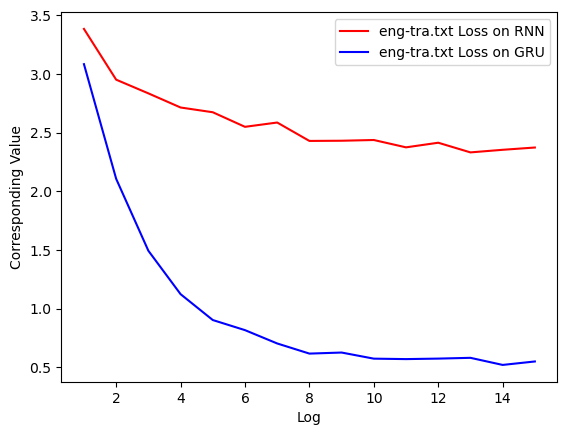

In [14]:
plt.figure()
plt.plot(np.arange(1,16),eng_fra_losses_rnn,color='red',label='eng-tra.txt Loss on RNN')
plt.plot(np.arange(1,16),eng_fra_losses_gru,color='blue',label='eng-tra.txt Loss on GRU')
plt.legend()
plt.xlabel('Log')
plt.ylabel('Corresponding Value')
plt.show()

**可以明显看到gru最终损失显著小于rnn，模型收敛效果好**

### 基于eng-cmn.txt对RNN网络进行训练和测试

In [7]:
#注意这时候我们需要对lang进行更换了

print("\n============================")
print("     训练 RNN 模型")
print("============================")

hidden_size = 128

encoder_rnn = EncoderRNN(input_lang2.n_words, hidden_size, cell_type='rnn')  
decoder_rnn = DecoderRNN(hidden_size, output_lang2.n_words, cell_type='rnn')
eng_cmn_losses_rnn=trainIters(input_lang2,output_lang2,pairs2,encoder_rnn, decoder_rnn, n_iters=15000)

evaluateRandomly(input_lang2,output_lang2,pairs2,encoder_rnn, decoder_rnn)


     训练 RNN 模型
开始训练...
[1000/15000] 平均损失: 3.3578
[2000/15000] 平均损失: 3.0604
[3000/15000] 平均损失: 2.8026
[4000/15000] 平均损失: 2.7131
[5000/15000] 平均损失: 2.6347
[6000/15000] 平均损失: 2.5293
[7000/15000] 平均损失: 2.4992
[8000/15000] 平均损失: 2.4270
[9000/15000] 平均损失: 2.3496
[10000/15000] 平均损失: 2.3177
[11000/15000] 平均损失: 2.1903
[12000/15000] 平均损失: 2.2065
[13000/15000] 平均损失: 2.1646
[14000/15000] 平均损失: 2.1958
[15000/15000] 平均损失: 2.1507

==== 随机翻译测试 ====
输入: who are we ?
目标: 我們是誰 ？
输出: 汤姆是谁？
------------------------------
输入: be on time .
目标: 要守时 ！
输出: 让我以
------------------------------
输入: how cute !
目标: 多可爱啊 ！
输出: 多可爱！
------------------------------
输入: i'm now .
目标: 我现在 岁了 。
输出: 我很累。
------------------------------
输入: are you tom ?
目标: 你是汤姆吗 ？
输出: 你能看嗎？
------------------------------
输入: don't leave !
目标: 別走 ！
输出: 多可爱！
------------------------------
输入: fantastic !
目标: 好棒 ！
输出: 我們！
------------------------------
输入: step on it !
目标: 快一點 ！
输出: 我們！
------------------------------
输入: how curious !
目标: 真奇怪 

**同样的，rnn的预测效果依旧极差，预测出的结果语言毫无逻辑可言**

### 基于eng-cmn.txt对GRU网络进行训练和测试

In [8]:
print("\n============================")
print("     训练 GRU 模型")
print("============================")

hidden_size = 128

encoder_rnn = EncoderRNN(input_lang2.n_words, hidden_size, cell_type='gru')  
decoder_rnn = DecoderRNN(hidden_size, output_lang2.n_words, cell_type='gru')
eng_cmn_losses_gru=trainIters(input_lang2,output_lang2,pairs2,encoder_rnn, decoder_rnn, n_iters=15000)

evaluateRandomly(input_lang2,output_lang2,pairs2,encoder_rnn, decoder_rnn)


     训练 GRU 模型
开始训练...
[1000/15000] 平均损失: 3.2125
[2000/15000] 平均损失: 2.5222
[3000/15000] 平均损失: 2.0592
[4000/15000] 平均损失: 1.5591
[5000/15000] 平均损失: 1.1139
[6000/15000] 平均损失: 0.8395
[7000/15000] 平均损失: 0.6564
[8000/15000] 平均损失: 0.4469
[9000/15000] 平均损失: 0.4319
[10000/15000] 平均损失: 0.4463
[11000/15000] 平均损失: 0.3532
[12000/15000] 平均损失: 0.3438
[13000/15000] 平均损失: 0.3594
[14000/15000] 平均损失: 0.2551
[15000/15000] 平均损失: 0.3017

==== 随机翻译测试 ====
输入: come home .
目标: 回家吧 。
输出: 回家吧。
------------------------------
输入: hello !
目标: 你好 。
输出: 你好。
------------------------------
输入: i'm buying .
目标: 我买了 。
输出: 我买了。
------------------------------
输入: i was shy .
目标: 我害羞 。
输出: 我害羞。
------------------------------
输入: terrific !
目标: 很棒 ！
输出: 很棒！
------------------------------
输入: i am full .
目标: 我吃飽了 。
输出: 我吃飽了。
------------------------------
输入: thank you .
目标: 谢谢 。
输出: 谢谢。
------------------------------
输入: we try .
目标: 我们来试试 。
输出: 我们来试试。
------------------------------
输入: what's new ?
目标: 有什么新鲜事吗 ？
输出: 有什么新鲜事

**令人惊喜的是gru的随机测试结果竟然和目标结果完全一致，虽然我们在Encoder和Decoder中使用了LayerNorm，但也不排除过拟合的可能性  
即便如此，gru比起rnn的显著优势也一目了然，在相对简单的网络结构和训练环节下gru能很好地学会简单句子的语言逻辑**

### eng-cmn.txt上RNN网络和GRU网络表现对比

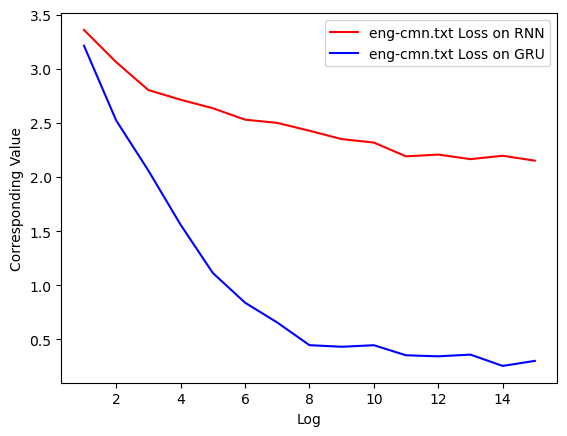

In [15]:
plt.figure()
plt.plot(np.arange(1,16),eng_cmn_losses_rnn,color='red',label='eng-cmn.txt Loss on RNN')
plt.plot(np.arange(1,16),eng_cmn_losses_gru,color='blue',label='eng-cmn.txt Loss on GRU')
plt.legend()
plt.xlabel('Log')
plt.ylabel('Corresponding Value')
plt.show()

**同样的，在eng-cmn.txt上gru最终损失显著小于rnn，模型收敛效果好**